# Human Capital Analysis Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Update these paths to match your folder structure
DATA_DIR = "C:/Users/Gorata/IndabaX/Data_Clean"

In [3]:
hcp_df = pd.read_csv(f"{DATA_DIR}/human_capital_dataset.csv")

In [4]:
hcp_df.head()

,Year,BWA_education,BWA_life_expectancy,KEN_education,KEN_life_expectancy,NAM_education,NAM_life_expectancy,ZAF_education,ZAF_life_expectancy,ZWE_education,...,KEN_FAO_CP_23014,NAM_FAO_CP_23012,NAM_FAO_CP_23013,NAM_FAO_CP_23014,ZAF_FAO_CP_23012,ZAF_FAO_CP_23013,ZAF_FAO_CP_23014,ZWE_FAO_CP_23012,ZWE_FAO_CP_23013,ZWE_FAO_CP_23014
0,2001,7.48678,52.210,2.88300,56.501,7.40270,51.980,NaN,57.161,NaN,...,7.878677,41.239459,35.208023,9.424651,48.680144,37.246317,5.371810,90.419642,92.069590,1.866212
1,2002,7.80341,52.373,2.87672,56.759,6.05017,51.988,NaN,55.580,NaN,...,2.602176,48.545440,40.524090,15.036091,53.302185,43.724882,17.334486,91.272041,93.756278,1.832022
2,2003,9.07960,52.851,NaN,57.369,6.39103,51.918,NaN,54.245,NaN,...,13.191143,52.009717,44.191891,9.301030,56.329442,47.294785,8.426041,92.124441,95.442967,1.799062
3,2004,9.56878,53.573,2.96267,57.947,NaN,52.175,NaN,53.963,NaN,...,15.948863,54.161168,44.623376,0.978517,55.939620,47.968487,1.425693,92.976840,97.129655,1.767267
4,2005,9.23078,54.386,3.00100,58.510,7.10705,52.557,NaN,53.914,NaN,...,13.693719,55.397096,45.213940,1.326474,57.093572,48.778461,1.689938,93.829240,98.816343,1.736576


In [5]:
hcp_df.columns

Index(['Year', 'BWA_education', 'BWA_life_expectancy', 'KEN_education',
       'KEN_life_expectancy', 'NAM_education', 'NAM_life_expectancy',
       'ZAF_education', 'ZAF_life_expectancy', 'ZWE_education',
       'ZWE_life_expectancy', 'BWA_FAO_CP_23012', 'BWA_FAO_CP_23013',
       'BWA_FAO_CP_23014', 'KEN_FAO_CP_23012', 'KEN_FAO_CP_23013',
       'KEN_FAO_CP_23014', 'NAM_FAO_CP_23012', 'NAM_FAO_CP_23013',
       'NAM_FAO_CP_23014', 'ZAF_FAO_CP_23012', 'ZAF_FAO_CP_23013',
       'ZAF_FAO_CP_23014', 'ZWE_FAO_CP_23012', 'ZWE_FAO_CP_23013',
       'ZWE_FAO_CP_23014'],
      dtype='object')

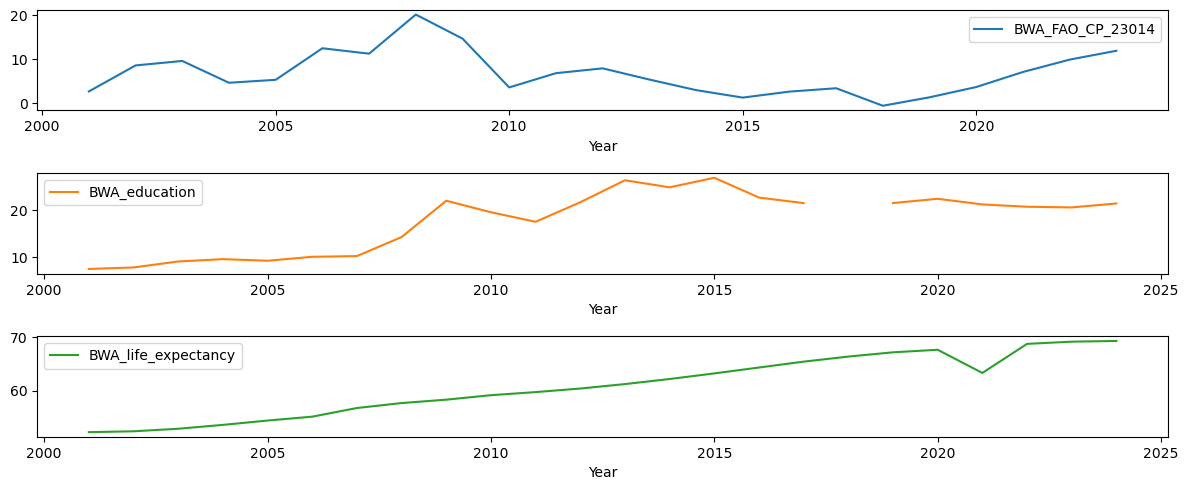

In [6]:
# Inspect time series
hcp_df.plot(x="Year", y=["BWA_FAO_CP_23014", "BWA_education", "BWA_life_expectancy"], subplots=True, layout=(3, 1), figsize=(12, 5), sharex=False)

plt.tight_layout()

plt.savefig(r'C:/Users/Gorata/IndabaX/HCP_Images/time_series.png')

plt.show()

## Regression Analysis

In [7]:
hcp_df = hcp_df.dropna(subset=["BWA_education"])
hcp_df = hcp_df.dropna(subset=["BWA_FAO_CP_23014"])

In [8]:
import statsmodels.api as sm

# Define dependent variable
y = hcp_df["BWA_FAO_CP_23014"]

# Define independent variables
X = hcp_df[
    [
        "BWA_education",
        "BWA_life_expectancy"
    ]
]

# Add constant
X = sm.add_constant(X)

# Run regression
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       BWA_FAO_CP_23014   R-squared:                       0.087
Model:                            OLS   Adj. R-squared:                 -0.009
Method:                 Least Squares   F-statistic:                    0.9099
Date:                Fri, 24 Jul 2026   Prob (F-statistic):              0.419
Time:                        22:02:44   Log-Likelihood:                -64.216
No. Observations:                  22   AIC:                             134.4
Df Residuals:                      19   BIC:                             137.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   7.9974    

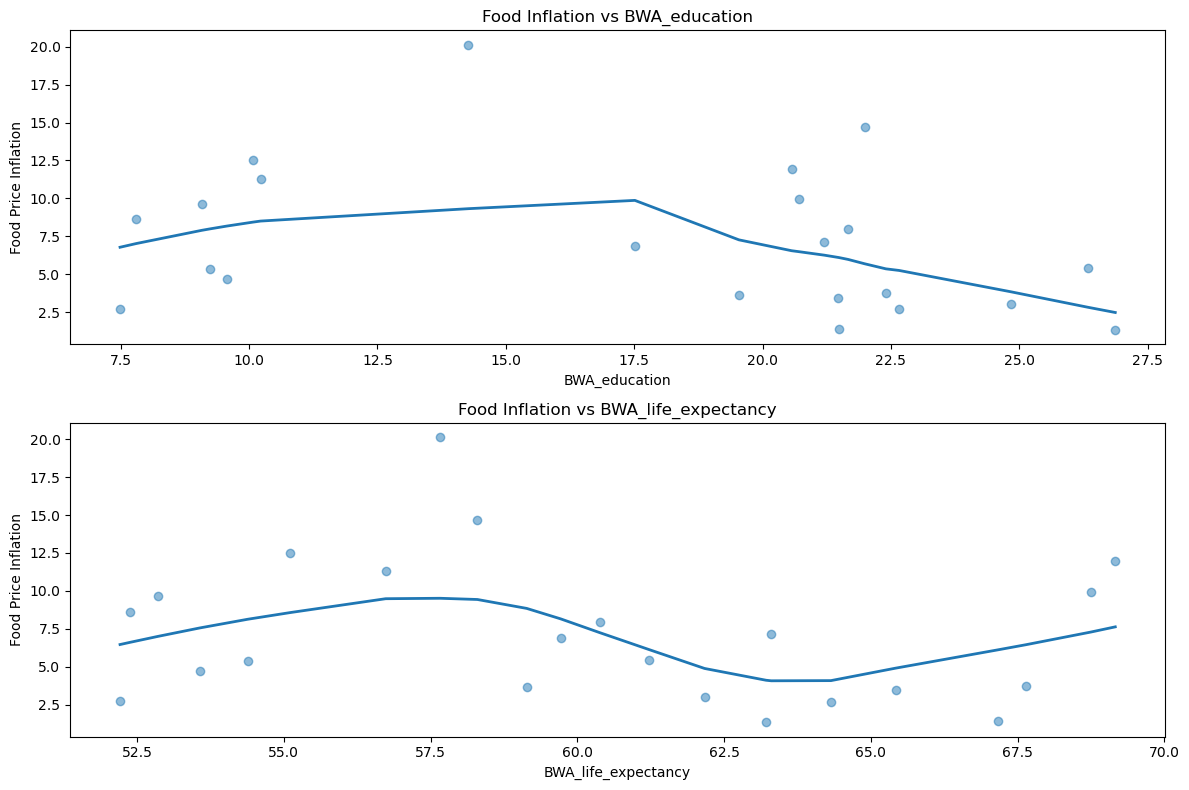

In [11]:
# Plot lowess plots
features = [
    "BWA_education",
    "BWA_life_expectancy"
]

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), features):
    sns.regplot(
        data=hcp_df,
        x=feature,
        y="BWA_FAO_CP_23014",
        lowess=True,
        scatter_kws={"alpha":0.5},
        line_kws={"linewidth":2},
        ax=ax
    )
    
    ax.set_title(f"Food Inflation vs {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Food Price Inflation")

plt.tight_layout()
plt.savefig(r'C:/Users/Gorata/IndabaX/HCP_Images/lowess_plots.png')
plt.show()

## Granger Causality Test

In [10]:
from statsmodels.tsa.stattools import grangercausalitytests

# Define the dependent variable
dependent_var = 'BWA_FAO_CP_23014'

# Define the independent variables to test
independent_vars = ['BWA_education', 'BWA_life_expectancy']

# Determine the maximum number of lags to test. We expect longer lag lengths due to the Botswana goverment's prudent policies to shield
# the economy

max_lags = 3

print(f"Performing Granger Causality Tests (maxlags={max_lags}):\n")

for ind_var in independent_vars:
    print(f"--- Testing if {ind_var} Granger-causes {dependent_var} ---")
    # Combine the dependent and independent variables for the test
    data_for_test = hcp_df[[dependent_var, ind_var]].dropna()

    # Perform the Granger Causality test
    # output=False suppresses the verbose output, only returns results dictionary
    granger_results = grangercausalitytests(data_for_test, maxlag=max_lags, verbose=False)

    # Interpret results for each lag
    for lag in range(1, max_lags + 1):
        test_results = granger_results[lag]
        # We usually look at the F-statistic p-value (test 'ssr_ftest')
        p_value = test_results[0]['ssr_ftest'][1]
        print(f"  Lag {lag}: p-value = {p_value:.4f}")
        if p_value < 0.05:
            print(f"    (Reject H0: {ind_var} Granger-causes {dependent_var} at 5% significance level)")
        else:
            print(f"    (Fail to reject H0: {ind_var} does not Granger-cause {dependent_var} at 5% significance level)")
    print("\n")

Performing Granger Causality Tests (maxlags=3):

--- Testing if BWA_education Granger-causes BWA_FAO_CP_23014 ---
  Lag 1: p-value = 0.0216
    (Reject H0: BWA_education Granger-causes BWA_FAO_CP_23014 at 5% significance level)
  Lag 2: p-value = 0.0527
    (Fail to reject H0: BWA_education does not Granger-cause BWA_FAO_CP_23014 at 5% significance level)
  Lag 3: p-value = 0.1912
    (Fail to reject H0: BWA_education does not Granger-cause BWA_FAO_CP_23014 at 5% significance level)


--- Testing if BWA_life_expectancy Granger-causes BWA_FAO_CP_23014 ---
  Lag 1: p-value = 0.4764
    (Fail to reject H0: BWA_life_expectancy does not Granger-cause BWA_FAO_CP_23014 at 5% significance level)
  Lag 2: p-value = 0.7728
    (Fail to reject H0: BWA_life_expectancy does not Granger-cause BWA_FAO_CP_23014 at 5% significance level)
  Lag 3: p-value = 0.8060
    (Fail to reject H0: BWA_life_expectancy does not Granger-cause BWA_FAO_CP_23014 at 5% significance level)


